In [243]:
#Loading in Packages and Data

#Importing Packages
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import ScalarFormatter
import matplotlib.gridspec as gridspec
import xarray as xr
import os; import time
import pickle
import h5py
###############################################################
def coefs(coefficients,degree):
    coef=coefficients
    coefs=""
    for n in range(degree, -1, -1):
        string=f"({coefficients[len(coef)-(n+1)]:.1e})"
        coefs+=string + f"x^{n}"
        if n != 0:
            coefs+=" + "
    return coefs
###############################################################

# Importing Model Data
check=False
dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'

# dx = 1 km; Np = 1M; Nt = 5 min
data=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_1km_5min.nc') #***
parcel=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_pdata_1km_5min_1e6.nc') #***
res='1km';t_res='5min'
Np_str='1e6'

# dx = 1km; Np = 50M
#Importing Model Data
check=False
dir2='/home/air673/koa_scratch/'
data=xr.open_dataset(dir2+'cm1out_1km_1min.nc') #***
parcel=xr.open_dataset(dir2+'cm1out_pdata_1km_1min_50M.nc') #***
res='1km'; t_res='1min'; Np_str='50e6'

In [244]:
times=data['time'].values/(1e9 * 60); times=times.astype(float);
minutes=1/times[1] #1 / minutes per timestep = timesteps per minute
job_array=False;index_adjust=0
ocean_fraction=2/8

In [245]:
import sys
dir2='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
path=dir2+'../Functions/'
sys.path.append(path)

import NumericalFunctions
from NumericalFunctions import * # import NumericalFunctions 
import PlottingFunctions
from PlottingFunctions import * # import PlottingFunctions


# # Get all functions in NumericalFunctions
# import inspect
# functions = [f[0] for f in inspect.getmembers(NumericalFunctions, inspect.isfunction)]
# functions

# # Get all functions in NumericalFunctions
# import inspect
# functions = [f[0] for f in inspect.getmembers(PlottingFunctions, inspect.isfunction)]
# functions

In [246]:
#CL VS NONCL
################################################################

In [247]:
##########################################################
#PLOTTING

In [248]:
def averaged_profiles(profile):
    out_var = profile[(profile[:, 1] != 0)]  # gets rid of rows that have no data
    out_var = np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T  # divides the data column by the counter column
    return out_var

In [249]:
def LoadAllCloudBase():
    dir2 = dir + f'Project_Algorithms/Tracking_Algorithms/'
    in_file = dir2 + f"all_cloudbase_{res}_{t_res}_{Np_str}.pkl"
    with open(in_file, 'rb') as f:
        all_cloudbase = pickle.load(f)
    return(all_cloudbase)
min_all_cloudbase=np.nanmin(LoadAllCloudBase())
all_cloudbase=min_all_cloudbase
print(f"Minimum Cloudbase is: {min_all_cloudbase}\n")

Minimum Cloudbase is: 1.2463867664337158



In [250]:
PROCESSING=False
PROCESSING=True

In [251]:
#NEEDED TO PLOT THE CORRECT DATA #*#*
data_type="Tracked_Entrainment_VMF"

In [252]:
type3='general'
type3='cloudy'

type1='CL';type2='nonCL'
dir3=dir+'Project_Algorithms/Tracked_Profiles/OUTPUT_FILES/'
filePath=dir3+f"{data_type}_"+f"{type1}_{type2}_tracked_profiles_{res}_{t_res}_{Np_str}.h5" 
if PROCESSING==False:
    filePath=dir3 + f"{data_type}_" + f"{type1}_{type2}_tracked_profiles_{res}_{t_res}_{Np_str}_ORIGINAL.h5"
with h5py.File(filePath, 'r') as h5f:
    for key in h5f.keys():
        globals()[key] = h5f[key][:]
        # print(key)

#this is needed because I wanted to keep consistent with the titles in "profile"
for ednet in ['e','d','net']:
    suffix = '_C' if type3 == 'cloudy' else '_G'
    for prefix in [type1, type2]:
        for group in ['ALL', 'SHALLOW', 'DEEP']:
            var_name = f"{prefix}_{group}_profile_array_{ednet.upper()}{suffix}"
            var_name_target = f"{prefix}_{group}_{ednet}"
            globals()[var_name_target] = globals()[var_name]
            print(f"{var_name_target} = {var_name}")



CL_ALL_e = CL_ALL_profile_array_E_C
CL_SHALLOW_e = CL_SHALLOW_profile_array_E_C
CL_DEEP_e = CL_DEEP_profile_array_E_C
nonCL_ALL_e = nonCL_ALL_profile_array_E_C
nonCL_SHALLOW_e = nonCL_SHALLOW_profile_array_E_C
nonCL_DEEP_e = nonCL_DEEP_profile_array_E_C
CL_ALL_d = CL_ALL_profile_array_D_C
CL_SHALLOW_d = CL_SHALLOW_profile_array_D_C
CL_DEEP_d = CL_DEEP_profile_array_D_C
nonCL_ALL_d = nonCL_ALL_profile_array_D_C
nonCL_SHALLOW_d = nonCL_SHALLOW_profile_array_D_C
nonCL_DEEP_d = nonCL_DEEP_profile_array_D_C
CL_ALL_net = CL_ALL_profile_array_NET_C
CL_SHALLOW_net = CL_SHALLOW_profile_array_NET_C
CL_DEEP_net = CL_DEEP_profile_array_NET_C
nonCL_ALL_net = nonCL_ALL_profile_array_NET_C
nonCL_SHALLOW_net = nonCL_SHALLOW_profile_array_NET_C
nonCL_DEEP_net = nonCL_DEEP_profile_array_NET_C


In [253]:
data_type2="Tracked_Combined_Entrainment"
type1='CL';type2='nonCL'
dir3=dir+'Project_Algorithms/Tracked_Profiles/OUTPUT_FILES/'
filePath=dir3 + f"{data_type2}_" + f"{type1}_{type2}_tracked_profiles_{res}_{t_res}_{Np_str}.h5"
if PROCESSING==False:
    filePath=dir3 + f"{data_type2}_" + f"{type1}_{type2}_tracked_profiles_{res}_{t_res}_{Np_str}_ORIGINAL.h5"
with h5py.File(filePath, 'r') as h5f:
    for key in h5f.keys():
        globals()[key] = h5f[key][:]
        print(key)

CL_ALL_profile_array_C_TO_G
CL_ALL_profile_array_G_TO_C
CL_DEEP_profile_array_C_TO_G
CL_DEEP_profile_array_G_TO_C
CL_SHALLOW_profile_array_C_TO_G
CL_SHALLOW_profile_array_G_TO_C
nonCL_ALL_profile_array_C_TO_G
nonCL_ALL_profile_array_G_TO_C
nonCL_DEEP_profile_array_C_TO_G
nonCL_DEEP_profile_array_G_TO_C
nonCL_SHALLOW_profile_array_C_TO_G
nonCL_SHALLOW_profile_array_G_TO_C


In [254]:
def PlotProfiles(ax,type1,type2,type3):
    lw = 1
    cutoff_height = 100
    z_cutoff = np.where(CL_ALL_net[:, 2] <= cutoff_height)[0][-1]

    profiles = [
        (globals()[f"{type1}_ALL_{type3}"], globals()[f"{type1}_SHALLOW_{type3}"], globals()[f"{type1}_DEEP_{type3}"], type1),
        (globals()[f"{type2}_ALL_{type3}"], globals()[f"{type2}_SHALLOW_{type3}"], globals()[f"{type2}_DEEP_{type3}"], type2)
    ]

    for ALL_profile_array, SHALLOW_profile_array, DEEP_profile_array, label in profiles:
        ALL_profile = averaged_profiles(ALL_profile_array)[:z_cutoff]
        SHALLOW_profile = averaged_profiles(SHALLOW_profile_array)[:z_cutoff]
        DEEP_profile = averaged_profiles(DEEP_profile_array)[:z_cutoff]

        if label == type1:
            ax.plot(ALL_profile[:, 0], ALL_profile[:, -1], linestyle='solid',color='black', label=f'ALL ({type1})', lw=lw)
            ax.plot(SHALLOW_profile[:, 0], SHALLOW_profile[:, -1], linestyle='solid', color='green', label=f'SHALLOW ({type1})', lw=lw)
            ax.plot(DEEP_profile[:, 0], DEEP_profile[:, -1], linestyle='solid',color='blue', label=f'DEEP ({type1})', lw=lw)
        else:
            ax.plot(ALL_profile[:, 0], ALL_profile[:, -1], linestyle='dashed', color='black', label=f'ALL ({type2})', lw=lw)
            ax.plot(SHALLOW_profile[:, 0], SHALLOW_profile[:, -1], linestyle='dashed', color='green', label=f'SHALLOW ({type2})', lw=lw)
            ax.plot(DEEP_profile[:, 0], DEEP_profile[:, -1], linestyle='dashed', color='blue', label=f'DEEP ({type2})', lw=lw)

        apply_scientific_notation([ax])

    ax.set_ylim(0, 3)
    ax.set_xlabel('x-axis label')  # Update label if needed
    ax.set_ylabel('z (km)')
    ax.grid(True)
    ax.axvline(0, linestyle='dashed', color='grey', zorder=-10)
    ax.axhline(all_cloudbase, color='purple', linestyle='dashed')
    ax.legend(fontsize=8)

def PlotTwo(ax,type1,type2):
    lw=1
    
    # List of profile arrays and their corresponding labels and x-axis titles
    profiles = [
        (CL_ALL_profile_array_G_TO_C, CL_SHALLOW_profile_array_G_TO_C, CL_DEEP_profile_array_G_TO_C, 'G_TO_C', type1),
        (nonCL_ALL_profile_array_G_TO_C, nonCL_SHALLOW_profile_array_G_TO_C, nonCL_DEEP_profile_array_G_TO_C, 'G_TO_C', type2)
    ]
    
    
    cutoff_height=100
    # z_cutoff=7.5
    z_cutoff=np.where(CL_ALL_profile_array_G_TO_C[:,2]<=cutoff_height)[0][-1] #CUT BELOW CERTAIN Z

    
    # Loop through profiles for CL and nonCL
    for i, (ALL_profile_array, SHALLOW_profile_array, DEEP_profile_array, xlabel,label) in enumerate(profiles):
        # Compute the averaged profile for ALL
        ALL_profile = averaged_profiles(ALL_profile_array)
        SHALLOW_profile = averaged_profiles(SHALLOW_profile_array)
        DEEP_profile = averaged_profiles(DEEP_profile_array)
    
        #CUT BELOW CERTAIN Z
        ALL_profile=ALL_profile[:z_cutoff]
        SHALLOW_profile=SHALLOW_profile[:z_cutoff]
        DEEP_profile=DEEP_profile[:z_cutoff]
    
        # Plot the profile for ALL (CL and nonCL) on top of each other
        if label == type1:
            ax.plot(ALL_profile[:, 0], ALL_profile[:, -1], color='black', label=f'ALL ({type1})',lw=lw)
            ax.plot(SHALLOW_profile[:, 0], SHALLOW_profile[:, -1], color='green', label=f'SHALLOW ({type1})',lw=lw)
            ax.plot(DEEP_profile[:, 0], DEEP_profile[:, -1], color='blue', label=f'DEEP ({type1})',lw=lw)
        else:
            ax.plot(ALL_profile[:, 0], ALL_profile[:, -1], linestyle='dashed', color='black', label=f'ALL ({type2})',lw=lw)
            ax.plot(SHALLOW_profile[:, 0], SHALLOW_profile[:, -1], linestyle='dashed', color='green', label=f'SHALLOW ({type2})',lw=lw)
            ax.plot(DEEP_profile[:, 0], DEEP_profile[:, -1], linestyle='dashed', color='blue', label=f'DEEP ({type2})',lw=lw)
    
        apply_scientific_notation([ax]) 
    
    # ax.set_ylim(0,3)
    
    # Add labels and title
    ax.set_ylim(0, 3)
    ax.set_xlabel('x-axis label')  # Replace with actual x-axis label
    ax.set_ylabel('z (km)')
    ax.grid(True)
    
    ax.axvline(0,linestyle='dashed',color='grey',zorder=-10)
    
    # Show legend
    ax.legend(fontsize=8)
    
    #MEAN CLOUD BASE
    ax.axhline(all_cloudbase,color='purple',linestyle='dashed')
    
    # Set up the main title and adjust layout
    # ax.set_title(f'CL vs nonCL (ALL, SHALLOW < 4 km, DEEP > 6 km) Vertical Profiles for \n Updraft General to Cloudy Entrainment from Tracked Lagrangian Parcels')
    plt.tight_layout()
    
    return ax


# #PLOTTING
# fig = plt.figure(figsize=(8, 6))
# ax = fig.add_subplot(111)
# ax2=PlotTwo(ax)

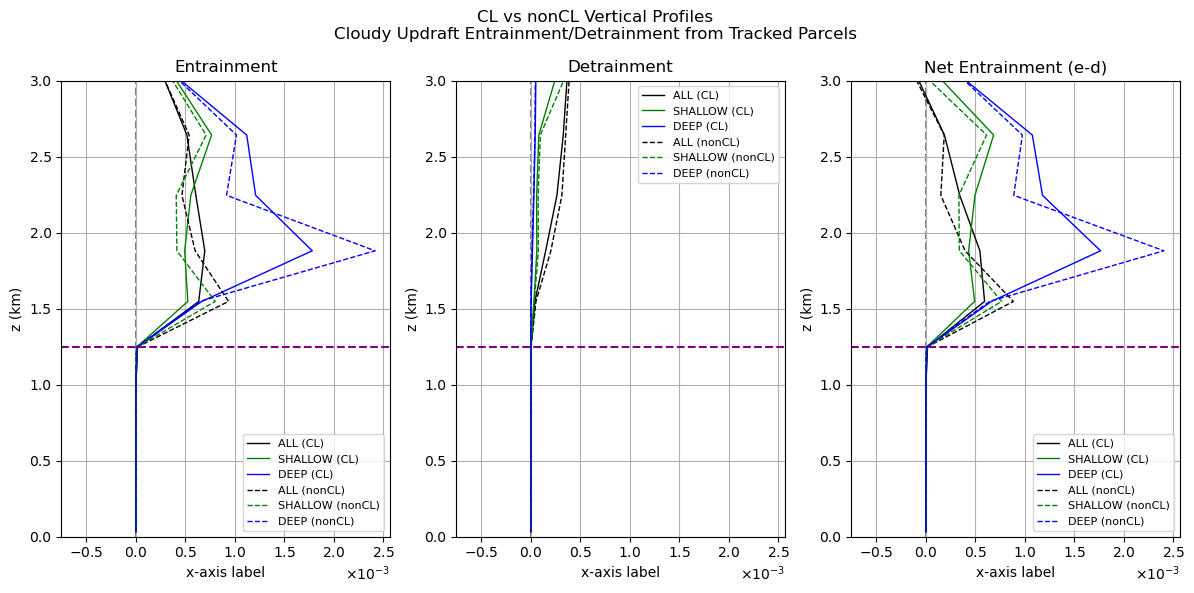

In [255]:
#PLOTTING
fig = plt.figure(figsize=(12, 6))
gs = fig.add_gridspec(1, 3)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])

# Run the plotting function separately for each axis
PlotProfiles(ax1,type1=type1,type2=type2,type3='e')
PlotProfiles(ax2,type1=type1,type2=type2,type3='d')
PlotProfiles(ax3,type1=type1,type2=type2,type3='net')
MatchAxisLimits([ax1,ax2,ax3],dim='x')

# Optional: customize titles for each panel
ax1.set_title('Entrainment')
ax2.set_title('Detrainment')
ax3.set_title('Net Entrainment (e-d)')

plt.suptitle(f'{type1} vs {type2} Vertical Profiles\n{type3.title()} Updraft Entrainment/Detrainment from Tracked Parcels')
plt.tight_layout()
plt.show()


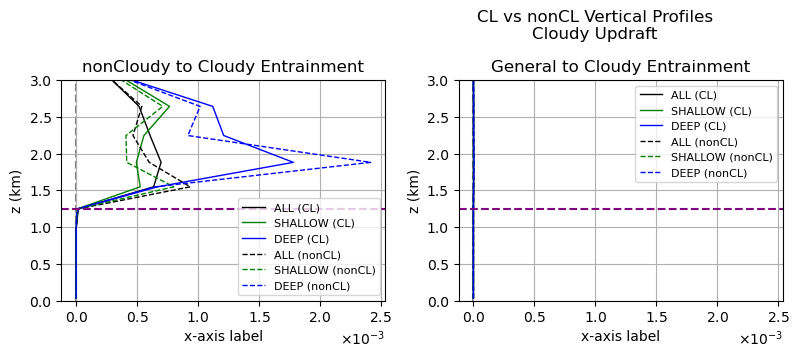

In [257]:
#PLOTTING
fig = plt.figure(figsize=(12, 6))
gs = fig.add_gridspec(2, 3)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])

# Run the plotting function separately for each axis
PlotProfiles(ax1,type1=type1,type2=type2,type3='e')
PlotTwo(ax2,type1=type1,type2=type2)
MatchAxisLimits([ax1,ax2],dim='x')

# Optional: customize titles for each panel
ax1.set_title('nonCloudy to Cloudy Entrainment')
ax2.set_title('General to Cloudy Entrainment')
plt.suptitle(f'{type1} vs {type2} Vertical Profiles\n{type3.title()} Updraft')
plt.tight_layout()

In [200]:
#DIFFERENCE PLOT
def average_difference(array1, array2):
    out_var_one=averaged_profiles(array1)
    out_var_two=averaged_profiles(array2)

    #masking out non matches
    second_col_one = out_var_one[:, 1]
    second_col_two = out_var_two[:, 1]
    mask_one = np.isin(second_col_one, second_col_two)
    mask_two = np.isin(second_col_two, second_col_one)
    
    out_var_one = out_var_one.copy()[mask_one]
    out_var_two = out_var_two.copy()[mask_two]
    
    diff=(out_var_one[:,0]-out_var_two[:,0])
    zs=out_var_one[:,1]

    out_profile=np.zeros((len(diff),2))

    out_profile[:,0]=diff;out_profile[:,1]=zs;
    return out_profile

# var_names = ['e','d','net']
# categories = ["ALL", "SHALLOW", "DEEP"]

# for var in var_names:
#     for cat in categories:
#         # Construct the variable names dynamically
#         CL_profile = globals()[f"CL_{cat}_{var}"]
#         nonCL_profile = globals()[f"nonCL_{cat}_{var}"]
        
#         # Calculate the difference and assign it to the global variable
#         globals()[f"{cat}_diff_{var}"] = average_difference(CL_profile, nonCL_profile)

var='net'
cat='DEEP'
CL_DEEP_profile=globals()[f"CL_{cat}_{var}"]
cat='SHALLOW'
CL_SHALLOW_profile=globals()[f"CL_{cat}_{var}"]
globals()[f"CL_diff_{var}"] = average_difference(CL_DEEP_profile, CL_SHALLOW_profile)


var='net'
cat='DEEP'
nonCL_DEEP_profile=globals()[f"nonCL_{cat}_{var}"]
cat='SHALLOW'
nonCL_SHALLOW_profile=globals()[f"nonCL_{cat}_{var}"]

globals()[f"nonCL_diff_{var}"] = average_difference(nonCL_DEEP_profile, nonCL_SHALLOW_profile)

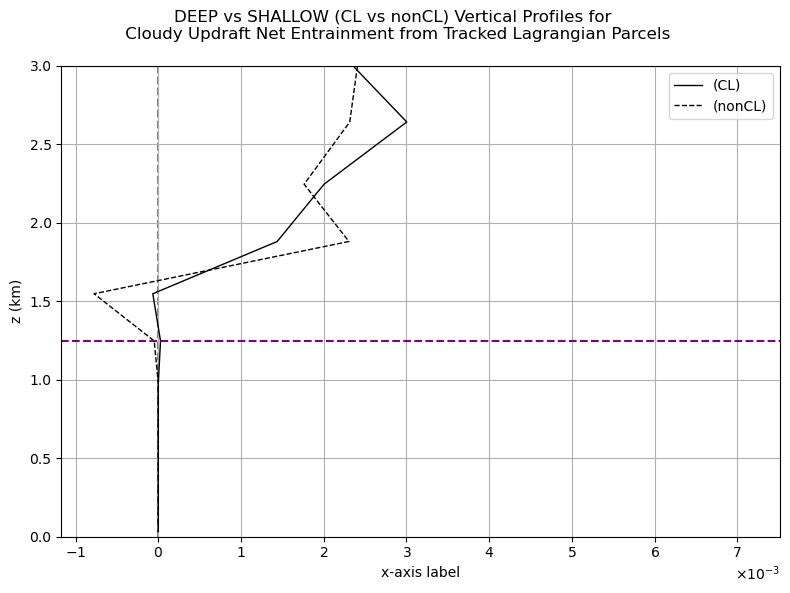

In [74]:
#REDUCING FOR CONFERENCE FIGURE
import matplotlib.pyplot as plt
lw=1

# List of profile arrays and their corresponding labels and x-axis titles
profiles = [
    (CL_diff_net,  'net', 'CL Diff'),
    (nonCL_diff_net,  'net', 'nonCL Diff'),
]

cutoff_height=100
# cutoff_height=7.5
# cutoff_height=2
z_cutoff=np.where(CL_ALL_net[:,2]<=cutoff_height)[0][-1] #CUT BELOW CERTAIN Z

# Set up the figure
fig = plt.figure(figsize=(8, 6))

# Create a single axis for all profiles
ax = fig.add_subplot(111)

# Loop through profiles for CL and nonCL
for i, (ALL_profile, xlabel, CLlabel) in enumerate(profiles):

    #CUT BELOW CERTAIN Z
    ALL_profile=ALL_profile[:z_cutoff]

    # Plot the profile for ALL (CL and nonCL) on top of each other
    if CLlabel == 'CL Diff':
        ax.plot(ALL_profile[:, 0], ALL_profile[:, -1], color='black', label='(CL)',lw=lw)
    else:
        ax.plot(ALL_profile[:, 0], ALL_profile[:, -1], linestyle='dashed', color='black', label='(nonCL)',lw=lw)
    apply_scientific_notation([ax])

if type3 in ['general','cloudy']:
    ax.set_ylim(0,3)

# Add labels and title
ax.set_xlabel('x-axis label')  # Replace with actual x-axis label
ax.set_ylabel('z (km)')
ax.grid(True)

ax.axvline(0,linestyle='dashed',color='grey',zorder=-10)

# Show legend
ax.legend()

#MEAN CLOUD BASE
ax.axhline(all_cloudbase,color='purple',linestyle='dashed')

# Set up the main title and adjust layout
plt.suptitle(f'DEEP vs SHALLOW (CL vs nonCL) Vertical Profiles for \n {type3.title()} Updraft Net Entrainment from Tracked Lagrangian Parcels')
plt.tight_layout()

# Show plot
plt.show()




In [15]:
##########################################################################################
#SBZ vs nonSBZ Tracked Entrainment Profiles

In [16]:
##########################################################
#PLOTTING

In [145]:
type3='general'
type3='cloudy'

type1='SBZ';type2='nonSBZ'
dir3=dir+'Project_Algorithms/Tracked_Profiles/OUTPUT_FILES/'
filePath=dir3+f"{data_type}_"+f"{type1}_{type2}_tracked_profiles_{res}_{t_res}_{Np_str}.h5" 
if PROCESSING==False:
    filePath=dir3 + f"{data_type}_" + f"{type1}_{type2}_tracked_profiles_{res}_{t_res}_{Np_str}_ORIGINAL.h5"
with h5py.File(filePath, 'r') as h5f:
    for key in h5f.keys():
        globals()[key] = h5f[key][:]
        # print(key)

#this is needed because I wanted to keep consistent with the titles in "profile"
for ednet in ['e','d','net']:
    suffix = '_C' if type3 == 'cloudy' else '_G'
    for prefix in [type1, type2]:
        for group in ['ALL', 'SHALLOW', 'DEEP']:
            var_name = f"{prefix}_{group}_profile_array_{ednet.upper()}{suffix}"
            var_name_target = f"{prefix}_{group}_{ednet}"
            globals()[var_name_target] = globals()[var_name]
            print(f"{var_name_target} = {var_name}")



SBZ_ALL_e = SBZ_ALL_profile_array_E_C
SBZ_SHALLOW_e = SBZ_SHALLOW_profile_array_E_C
SBZ_DEEP_e = SBZ_DEEP_profile_array_E_C
nonSBZ_ALL_e = nonSBZ_ALL_profile_array_E_C
nonSBZ_SHALLOW_e = nonSBZ_SHALLOW_profile_array_E_C
nonSBZ_DEEP_e = nonSBZ_DEEP_profile_array_E_C
SBZ_ALL_d = SBZ_ALL_profile_array_D_C
SBZ_SHALLOW_d = SBZ_SHALLOW_profile_array_D_C
SBZ_DEEP_d = SBZ_DEEP_profile_array_D_C
nonSBZ_ALL_d = nonSBZ_ALL_profile_array_D_C
nonSBZ_SHALLOW_d = nonSBZ_SHALLOW_profile_array_D_C
nonSBZ_DEEP_d = nonSBZ_DEEP_profile_array_D_C
SBZ_ALL_net = SBZ_ALL_profile_array_NET_C
SBZ_SHALLOW_net = SBZ_SHALLOW_profile_array_NET_C
SBZ_DEEP_net = SBZ_DEEP_profile_array_NET_C
nonSBZ_ALL_net = nonSBZ_ALL_profile_array_NET_C
nonSBZ_SHALLOW_net = nonSBZ_SHALLOW_profile_array_NET_C
nonSBZ_DEEP_net = nonSBZ_DEEP_profile_array_NET_C


In [177]:
data_type2="Tracked_Combined_Entrainment"
type1='SBZ';type2='nonSBZ'
dir3=dir+'Project_Algorithms/Tracked_Profiles/OUTPUT_FILES/'
filePath=dir3 + f"{data_type2}_" + f"{type1}_{type2}_tracked_profiles_{res}_{t_res}_{Np_str}.h5"
if PROCESSING==False:
    filePath=dir3 + f"{data_type2}_" + f"{type1}_{type2}_tracked_profiles_{res}_{t_res}_{Np_str}_ORIGINAL.h5"
with h5py.File(filePath, 'r') as h5f:
    for key in h5f.keys():
        globals()[key] = h5f[key][:]
        print(key)

SBZ_ALL_profile_array_C_TO_G
SBZ_ALL_profile_array_G_TO_C
SBZ_DEEP_profile_array_C_TO_G
SBZ_DEEP_profile_array_G_TO_C
SBZ_SHALLOW_profile_array_C_TO_G
SBZ_SHALLOW_profile_array_G_TO_C
nonSBZ_ALL_profile_array_C_TO_G
nonSBZ_ALL_profile_array_G_TO_C
nonSBZ_DEEP_profile_array_C_TO_G
nonSBZ_DEEP_profile_array_G_TO_C
nonSBZ_SHALLOW_profile_array_C_TO_G
nonSBZ_SHALLOW_profile_array_G_TO_C


In [178]:
# type1='SBZ';type2='nonSBZ'
# dir3=dir+'Project_Algorithms/Tracked_Profiles/OUTPUT_FILES/'
# filePath=dir3+f"{data_type}_"+f"{type1}_{type2}_tracked_profiles_SE_{res}_{t_res}_{Np_str}.h5"
# with h5py.File(filePath, 'r') as h5f:
#     for key in h5f.keys():
#         globals()[key] = h5f[key][:]
#         # print(key)

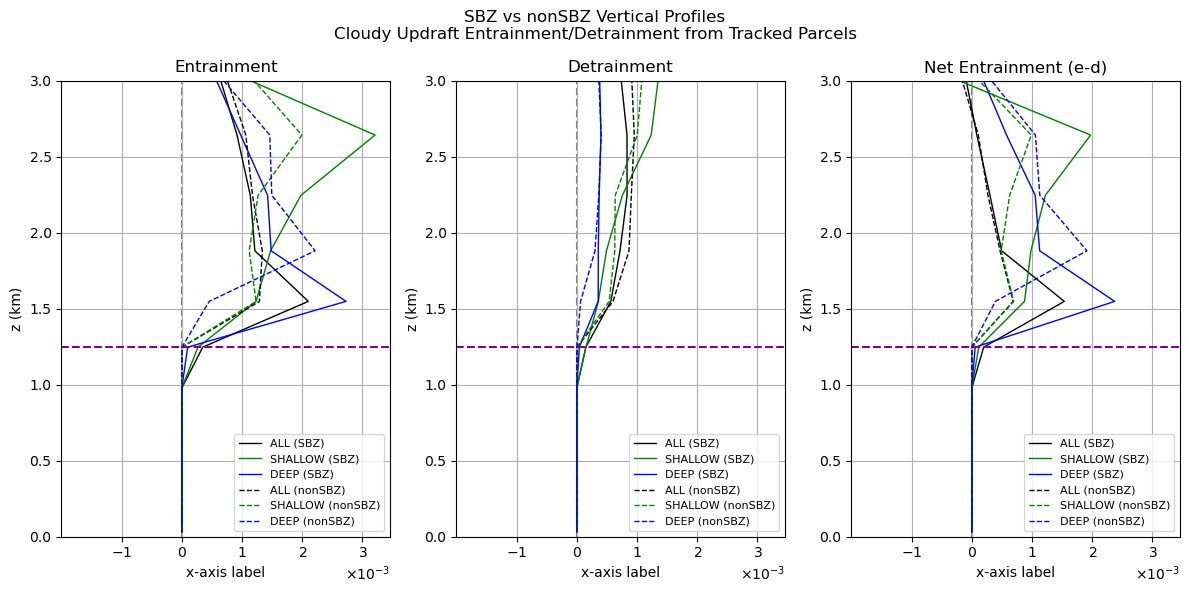

In [179]:
#PLOTTING
fig = plt.figure(figsize=(12, 6))
gs = fig.add_gridspec(1, 3)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])

# Run the plotting function separately for each axis
PlotProfiles(ax1,type1=type1,type2=type2,type3='e')
PlotProfiles(ax2,type1=type1,type2=type2,type3='d')
PlotProfiles(ax3,type1=type1,type2=type2,type3='net')
MatchAxisLimits([ax1,ax2,ax3],dim='x')

# Optional: customize titles for each panel
ax1.set_title('Entrainment')
ax2.set_title('Detrainment')
ax3.set_title('Net Entrainment (e-d)')

plt.suptitle(f'{type1} vs {type2} Vertical Profiles\n{type3.title()} Updraft Entrainment/Detrainment from Tracked Parcels')
plt.tight_layout()
plt.show()


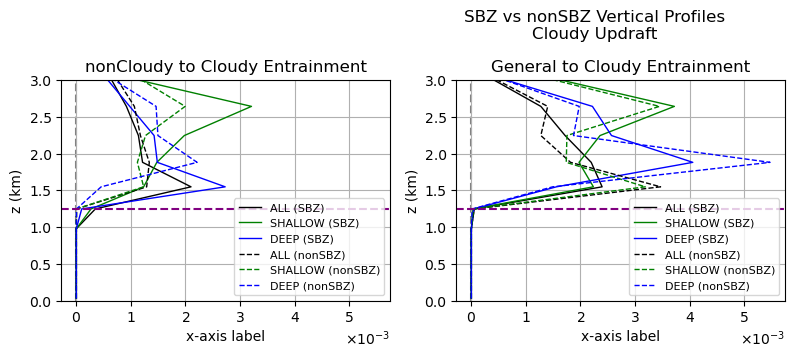

In [180]:
#PLOTTING
fig = plt.figure(figsize=(12, 6))
gs = fig.add_gridspec(2, 3)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])

# Run the plotting function separately for each axis
PlotProfiles(ax1,type1=type1,type2=type2,type3='e')
PlotTwo(ax2,type1=type1,type2=type2)
MatchAxisLimits([ax1,ax2],dim='x')

# Optional: customize titles for each panel
ax1.set_title('nonCloudy to Cloudy Entrainment')
ax2.set_title('General to Cloudy Entrainment')
plt.suptitle(f'{type1} vs {type2} Vertical Profiles\n{type3.title()} Updraft')
plt.tight_layout()

In [89]:
#DIFFERENCE PLOT
def average_difference(array1, array2):
    out_var_one=averaged_profiles(array1)
    out_var_two=averaged_profiles(array2)

    #masking out non matches
    second_col_one = out_var_one[:, 1]
    second_col_two = out_var_two[:, 1]
    mask_one = np.isin(second_col_one, second_col_two)
    mask_two = np.isin(second_col_two, second_col_one)
    
    out_var_one = out_var_one.copy()[mask_one]
    out_var_two = out_var_two.copy()[mask_two]
    
    diff=(out_var_one[:,0]-out_var_two[:,0])
    zs=out_var_one[:,1]

    out_profile=np.zeros((len(diff),2))

    out_profile[:,0]=diff;out_profile[:,1]=zs;
    return out_profile
var='net'
cat='DEEP'
SBZ_DEEP_profile=globals()[f"SBZ_{cat}_{var}"]
cat='SHALLOW'
SBZ_SHALLOW_profile=globals()[f"SBZ_{cat}_{var}"]
globals()[f"SBZ_diff_{var}"] = average_difference(SBZ_DEEP_profile, SBZ_SHALLOW_profile)

var='net'
cat='DEEP'
nonSBZ_DEEP_profile=globals()[f"nonSBZ_{cat}_{var}"]
cat='SHALLOW'
nonSBZ_SHALLOW_profile=globals()[f"nonSBZ_{cat}_{var}"]

globals()[f"nonSBZ_diff_{var}"] = average_difference(nonSBZ_DEEP_profile, nonSBZ_SHALLOW_profile)

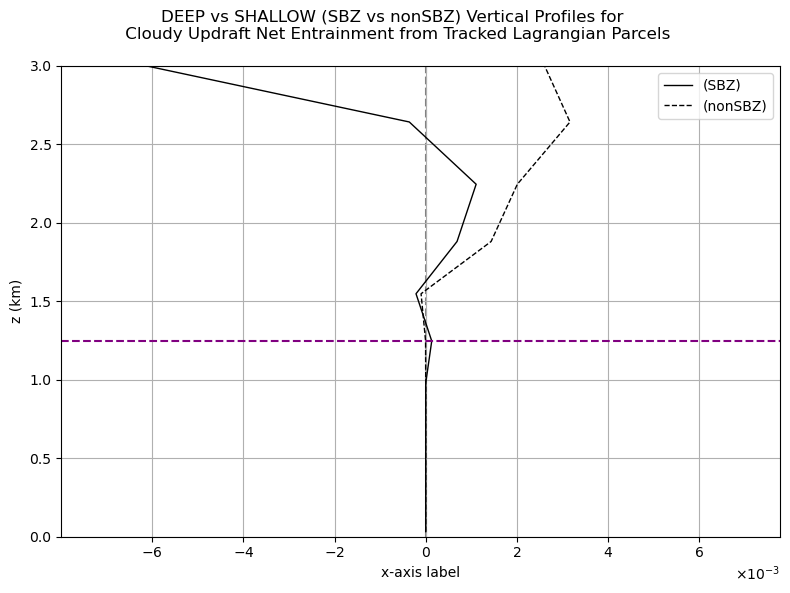

In [90]:
#REDUCING FOR CONFERENCE FIGURE
import matplotlib.pyplot as plt
lw=1

# List of profile arrays and their corresponding labels and x-axis titles
profiles = [
    (SBZ_diff_net,  'net', 'SBZ Diff'),
    (nonSBZ_diff_net,  'net', 'nonSBZ Diff'),
]

cutoff_height=100
# cutoff_height=7.5
# cutoff_height=2
z_cutoff=np.where(SBZ_ALL_net[:,2]<=cutoff_height)[0][-1] #CUT BELOW CERTAIN Z

# Set up the figure
fig = plt.figure(figsize=(8, 6))

# Create a single axis for all profiles
ax = fig.add_subplot(111)

# Loop through profiles for SBZ and nonSBZ
for i, (ALL_profile, xlabel, SBZlabel) in enumerate(profiles):

    #CUT BELOW CERTAIN Z
    ALL_profile=ALL_profile[:z_cutoff]

    # Plot the profile for ALL (SBZ and nonSBZ) on top of each other
    if SBZlabel == 'SBZ Diff':
        ax.plot(ALL_profile[:, 0], ALL_profile[:, -1], color='black', label='(SBZ)',lw=lw)
    else:
        ax.plot(ALL_profile[:, 0], ALL_profile[:, -1], linestyle='dashed', color='black', label='(nonSBZ)',lw=lw)
    apply_scientific_notation([ax])


if type3 in ['general','cloudy']:
    ax.set_ylim(0,3)

# Add labels and title
ax.set_xlabel('x-axis label')  # Replace with actual x-axis label
ax.set_ylabel('z (km)')
ax.grid(True)

ax.axvline(0,linestyle='dashed',color='grey',zorder=-10)

# Show legend
ax.legend()

#MEAN CLOUD BASE
ax.axhline(all_cloudbase,color='purple',linestyle='dashed')

# Set up the main title and adjust layout
plt.suptitle(f'DEEP vs SHALLOW (SBZ vs nonSBZ) Vertical Profiles for \n {type3.title()} Updraft Net Entrainment from Tracked Lagrangian Parcels')
plt.tight_layout()

# Show plot
plt.show()




In [23]:
#ColdPool
################################################################

In [24]:
########################
#PLOTTING

In [181]:
type3='general'
type3='cloudy'

type1='ColdPool';type2='SBZ'
dir3=dir+'Project_Algorithms/Tracked_Profiles/OUTPUT_FILES/'
filePath=dir3+f"{data_type}_"+f"{type1}_tracked_profiles_{res}_{t_res}_{Np_str}.h5" 
if PROCESSING==False:
    filePath=dir3 + f"{data_type}_" + f"{type1}_tracked_profiles_{res}_{t_res}_{Np_str}_ORIGINAL.h5"
with h5py.File(filePath, 'r') as h5f:
    for key in h5f.keys():
        globals()[key] = h5f[key][:]
        # print(key)

#this is needed because I wanted to keep consistent with the titles in "profile"
for ednet in ['e','d','net']:
    suffix = '_C' if type3 == 'cloudy' else '_G'
    for prefix in [type1]:
        for group in ['ALL', 'SHALLOW', 'DEEP']:
            var_name = f"{prefix}_{group}_profile_array_{ednet.upper()}{suffix}"
            var_name_target = f"{prefix}_{group}_{ednet}"
            globals()[var_name_target] = globals()[var_name]
            print(f"{var_name_target} = {var_name}")



ColdPool_ALL_e = ColdPool_ALL_profile_array_E_C
ColdPool_SHALLOW_e = ColdPool_SHALLOW_profile_array_E_C
ColdPool_DEEP_e = ColdPool_DEEP_profile_array_E_C
ColdPool_ALL_d = ColdPool_ALL_profile_array_D_C
ColdPool_SHALLOW_d = ColdPool_SHALLOW_profile_array_D_C
ColdPool_DEEP_d = ColdPool_DEEP_profile_array_D_C
ColdPool_ALL_net = ColdPool_ALL_profile_array_NET_C
ColdPool_SHALLOW_net = ColdPool_SHALLOW_profile_array_NET_C
ColdPool_DEEP_net = ColdPool_DEEP_profile_array_NET_C


In [182]:
type1='ColdPool'
dir3=dir+'Project_Algorithms/Tracked_Profiles/OUTPUT_FILES/'
filePath=dir3+f"{data_type2}_"+f"{type1}_tracked_profiles_{res}_{t_res}_{Np_str}.h5"
if PROCESSING==False:
    filePath=dir3 + f"{data_type2}_" + f"{type1}_tracked_profiles_{res}_{t_res}_{Np_str}_ORIGINAL.h5"
with h5py.File(filePath, 'r') as h5f:
    for key in h5f.keys():
        globals()[key] = h5f[key][:]
        print(key)

ColdPool_ALL_profile_array_C_TO_G
ColdPool_ALL_profile_array_G_TO_C
ColdPool_DEEP_profile_array_C_TO_G
ColdPool_DEEP_profile_array_G_TO_C
ColdPool_SHALLOW_profile_array_C_TO_G
ColdPool_SHALLOW_profile_array_G_TO_C


In [183]:
# type1='ColdPool'
# dir3=dir+'Project_Algorithms/Tracked_Profiles/OUTPUT_FILES/'
# filePath=dir3+f"{data_type}_"+f"{type1}_tracked_profiles_SE_{res}_{t_res}_{Np_str}.h5"
# with h5py.File(filePath, 'r') as h5f:
#     for key in h5f.keys():
#         globals()[key] = h5f[key][:]
#         # print(key)

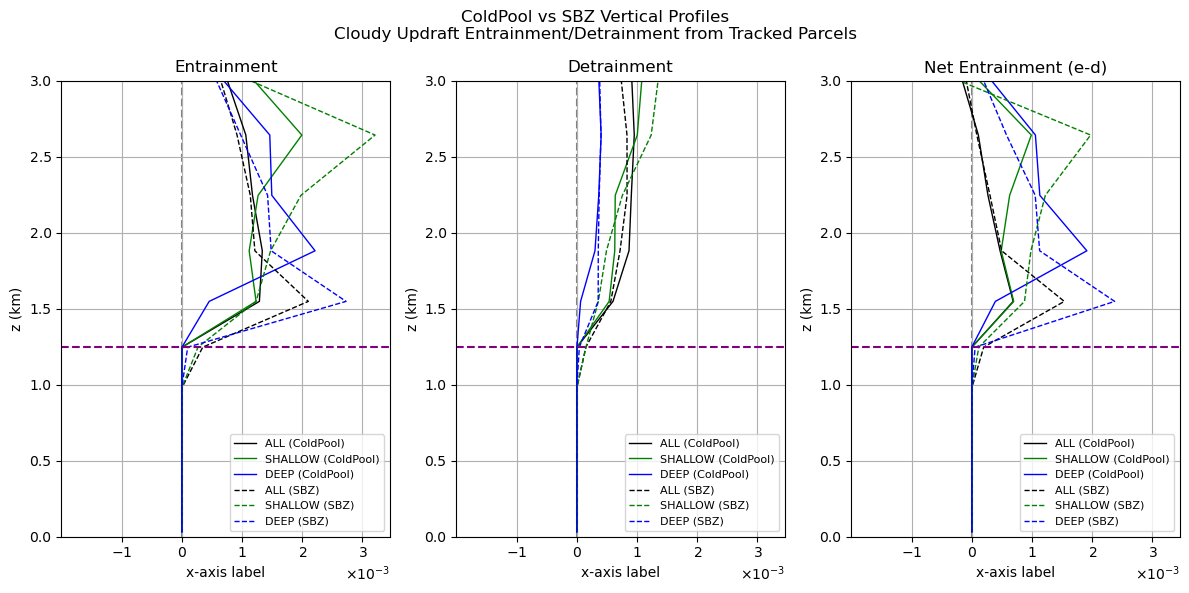

In [184]:
#PLOTTING
fig = plt.figure(figsize=(12, 6))
gs = fig.add_gridspec(1, 3)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])

# Run the plotting function separately for each axis
PlotProfiles(ax1,type1=type1,type2=type2,type3='e')
PlotProfiles(ax2,type1=type1,type2=type2,type3='d')
PlotProfiles(ax3,type1=type1,type2=type2,type3='net')

# Optional: customize titles for each panel
ax1.set_title('Entrainment')
ax2.set_title('Detrainment')
ax3.set_title('Net Entrainment (e-d)')
MatchAxisLimits([ax1,ax2,ax3],dim='x')

plt.suptitle(f'{type1} vs {type2} Vertical Profiles\n{type3.title()} Updraft Entrainment/Detrainment from Tracked Parcels')
plt.tight_layout()
plt.show()


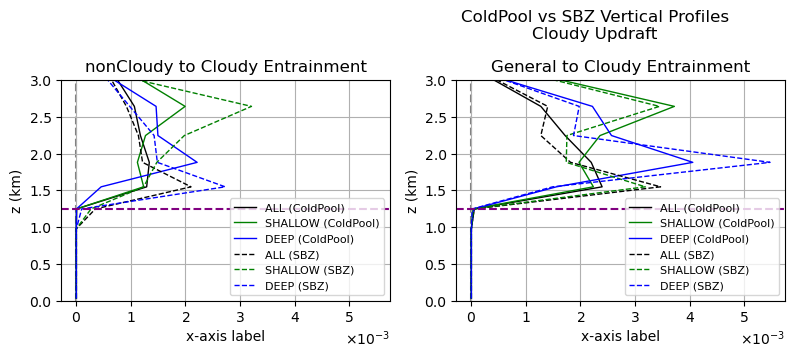

In [185]:
#PLOTTING
fig = plt.figure(figsize=(12, 6))
gs = fig.add_gridspec(2, 3)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])

# Run the plotting function separately for each axis
PlotProfiles(ax1,type1=type1,type2=type2,type3='e')
PlotTwo(ax2,type1=type1,type2=type2)
MatchAxisLimits([ax1,ax2],dim='x')

# Optional: customize titles for each panel
ax1.set_title('nonCloudy to Cloudy Entrainment')
ax2.set_title('General to Cloudy Entrainment')
plt.suptitle(f'{type1} vs {type2} Vertical Profiles\n{type3.title()} Updraft')
plt.tight_layout()

In [101]:
#DIFFERENCE PLOT
def average_difference(array1, array2):
    out_var_one=averaged_profiles(array1)
    out_var_two=averaged_profiles(array2)

    #masking out non matches
    second_col_one = out_var_one[:, 1]
    second_col_two = out_var_two[:, 1]
    mask_one = np.isin(second_col_one, second_col_two)
    mask_two = np.isin(second_col_two, second_col_one)
    
    out_var_one = out_var_one.copy()[mask_one]
    out_var_two = out_var_two.copy()[mask_two]
    
    diff=(out_var_one[:,0]-out_var_two[:,0])
    zs=out_var_one[:,1]

    out_profile=np.zeros((len(diff),2))

    out_profile[:,0]=diff;out_profile[:,1]=zs;
    return out_profile
var='net'
cat='DEEP'
SBZ_DEEP_profile=globals()[f"SBZ_{cat}_{var}"]
cat='SHALLOW'
SBZ_SHALLOW_profile=globals()[f"SBZ_{cat}_{var}"]
globals()[f"SBZ_diff_{var}"] = average_difference(SBZ_DEEP_profile, SBZ_SHALLOW_profile)

var='net'
cat='DEEP'
ColdPool_DEEP_profile=globals()[f"ColdPool_{cat}_{var}"]
cat='SHALLOW'
ColdPool_SHALLOW_profile=globals()[f"ColdPool_{cat}_{var}"]

globals()[f"ColdPool_diff_{var}"] = average_difference(ColdPool_DEEP_profile, ColdPool_SHALLOW_profile)

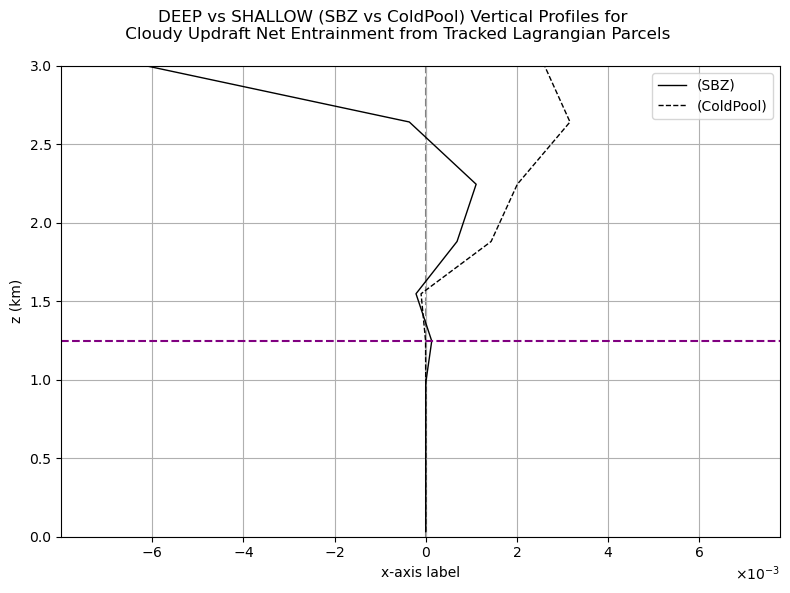

In [102]:
#REDUCING FOR CONFERENCE FIGURE
import matplotlib.pyplot as plt
lw=1

# List of profile arrays and their corresponding labels and x-axis titles
profiles = [
    (SBZ_diff_net,  'net', 'SBZ Diff'),
    (ColdPool_diff_net,  'net', 'ColdPool Diff'),
]

cutoff_height=100
# cutoff_height=7.5
# cutoff_height=2
z_cutoff=np.where(SBZ_ALL_net[:,2]<=cutoff_height)[0][-1] #CUT BELOW CERTAIN Z

# Set up the figure
fig = plt.figure(figsize=(8, 6))

# Create a single axis for all profiles
ax = fig.add_subplot(111)

# Loop through profiles for SBZ and ColdPool
for i, (ALL_profile, xlabel, SBZlabel) in enumerate(profiles):

    #CUT BELOW CERTAIN Z
    ALL_profile=ALL_profile[:z_cutoff]

    # Plot the profile for ALL (SBZ and ColdPool) on top of each other
    if SBZlabel == 'SBZ Diff':
        ax.plot(ALL_profile[:, 0], ALL_profile[:, -1], color='black', label='(SBZ)',lw=lw)
    else:
        ax.plot(ALL_profile[:, 0], ALL_profile[:, -1], linestyle='dashed', color='black', label='(ColdPool)',lw=lw)
    apply_scientific_notation([ax])

if type3 in ['general','cloudy']:
    ax.set_ylim(0,3)

# Add labels and title
ax.set_xlabel('x-axis label')  # Replace with actual x-axis label
ax.set_ylabel('z (km)')
ax.grid(True)

ax.axvline(0,linestyle='dashed',color='grey',zorder=-10)

# Show legend
ax.legend()

#MEAN CLOUD BASE
ax.axhline(all_cloudbase,color='purple',linestyle='dashed')

# Set up the main title and adjust layout
plt.suptitle(f'DEEP vs SHALLOW (SBZ vs ColdPool) Vertical Profiles for \n {type3.title()} Updraft Net Entrainment from Tracked Lagrangian Parcels')
plt.tight_layout()

# Show plot
plt.show()


